# Run an analysis pipeline on computed embeddings

This notebook demonstrates the GELOS analysis pipeline for pre-computed Earth Observation embeddings. First, a subset of embeddings are extracted. Then, these are transformed and used for modeling.

In [140]:
# top level imports

from pprint import pprint
from pathlib import Path
import yaml
from gelos.extraction import extract_embeddings
from gelos.transforms import TRANSFORMS
from gelos.models import MODELS
from gelos.analysis import load_chip_tracker
from gelos.plotting import PLOTS, build_style_from_config

In [141]:
# set up paths for this analysis run

raw_data_dir = Path("/app/data/raw")
embedding_dir = Path("/app/data/interim")
figures_dir = Path("/app/reports/figures")
yaml_path = Path("/app/configs/exp004_prithvi600.yaml")

In [142]:
# read yaml config and construct variables for this run automatically

with open(yaml_path, "r") as f:
    yaml_config = yaml.safe_load(f)

data_version = yaml_config['data_version']
chip_tracker_file = yaml_config["chip_tracker"]
chip_id_column = yaml_config["chip_id_column"]

chip_gdf = load_chip_tracker(data_root / chip_tracker_file)
chip_gdf = chip_gdf.set_index(chip_id_column)

config_stem = yaml_path.stem
output_dir = embedding_dir / data_version / config_stem
data_root = raw_data_dir / data_version

## Select embedding layer for this demonstration

In [143]:
# show embedding layer directories

embedding_dirs = list(output_dir.glob("*"))
for dir in embedding_dirs:
    print(str(dir))

/app/data/interim/v0.50.1/exp004_prithvi600/.embeddings_complete
/app/data/interim/v0.50.1/exp004_prithvi600/layer_31


In [144]:
# select embedding layer based on options

embedding_layer = "layer_31"
embeddings_directory = output_dir / embedding_layer

## Select extraction strategy for this demonstration

In [145]:
# show extraction strategies

print("Available straegies in config:\n------------")
for strategy_key, strategy_cfg in yaml_config["embedding_extraction_strategies"].items():
    print(f"{strategy_cfg['title']} -  strategy key: {strategy_key}")

Available straegies in config:
------------
CLS Token -  strategy key: cls_token
All Steps of Middle Patch -  strategy key: all_steps_of_middle_patch
All Patches from April to June -  strategy key: all_patches_from_april_to_june


In [146]:
# select strategy key from options

strategy_key = "all_steps_of_middle_patch"

## Extract embeddings

In [147]:
# slice embeddings according to slice args

slice_args = strategy_cfg["slice_args"]
strategy_title = strategy_cfg.get("title", strategy_key)
prefix = f"{config_stem}_{strategy_key}_{embedding_layer}"
layer_dir = output_dir / embedding_layer

# since we are using a sample, do not cache to disk
embeddings, chip_indices = extract_embeddings(
    embeddings_directory, n_sample=1000, slice_args=slice_args,
)

Processing embeddings: 1000it [00:06, 154.36it/s]


## Step 2: Transforms

In [148]:
# PCA transformation

pca_result = TRANSFORMS["pca"](embeddings)

2026-02-23 15:03:39.061 | INFO     | gelos.transforms:pca_from_embeddings:61 - running PCA: n_components=0.95


In [149]:
# t-SNE transformation

tsne_result = TRANSFORMS["tsne"](embeddings, perplexity=30)

2026-02-23 15:04:10.033 | INFO     | gelos.transforms:tsne_from_embeddings:31 - running t-SNE: perplexity=30, n_components=2, max_iter=1000


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.037s...
[t-SNE] Computed neighbors for 1000 samples in 1.138s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 14.088396
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.915260
[t-SNE] KL divergence after 1000 iterations: 0.912106


## Step 3: Plotting and Modeling

### t-SNE plot

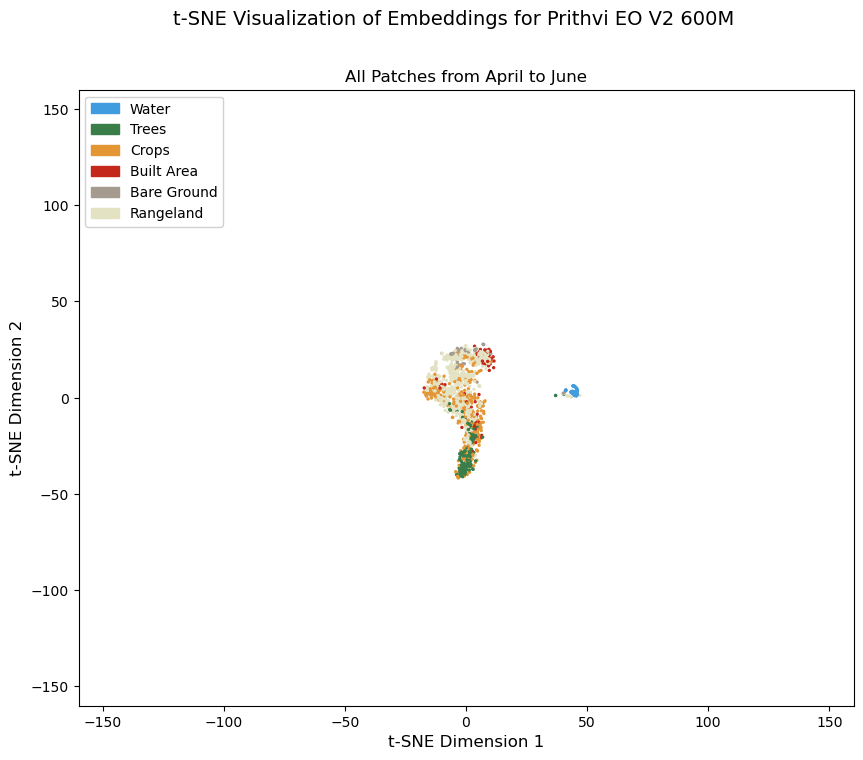

In [150]:
experiment_name = yaml_config["experiment_name"]
style_cfg = yaml_config["style"]
category_column, _, _ = build_style_from_config(style_cfg)

p_type = "tsne_scatter"
p_params = {
    "axis_lim" : 160
}

data = tsne_result
output_path = None
p_fn = PLOTS[p_type]
p_fn(
    data,
    chip_gdf,
    chip_indices,
    style_cfg,
    output_path,
    experiment_name,
    strategy_title,
    embedding_layer,
    **p_params,
)


### Run models with raw embeddings and outputs of t-SNE

In [151]:
# retrieve labels based on chip indices returned by embedding slicing
labels = chip_gdf[category_column].loc[chip_indices].to_numpy()

#### KNN Classifier

In [152]:
knn_results = MODELS["knn"](embeddings, labels, output_dir=Path("/app/reports"), run_name="knn_test")
print(f"KNN Accuracy on Sliced Embeddings: {knn_results['accuracy']}")
print(f"Per Class Accuracy on Sliced Embeddings: {knn_results['per_class']}")

2026-02-23 15:04:13.925 | INFO     | gelos.models:run_knn_cv:67 - running KNN CV: n_neighbors=5, n_splits=5
2026-02-23 15:04:19.494 | INFO     | gelos.models:run_knn_cv:85 - KNN overall accuracy: 0.6070
2026-02-23 15:04:19.497 | INFO     | gelos.models:_save_results_csv:39 - saved knn results to /app/reports/knn_test_knn_results.csv


KNN Accuracy on Sliced Embeddings: 0.607
Per Class Accuracy on Sliced Embeddings: {'1': 1.0, '11': 0.8752783964365256, '2': 0.7658227848101266, '5': 0.0, '7': 0.0, '8': 0.7115384615384616}


#### Random Forest Classifier

In [153]:
randomforest_results = MODELS["random_forest"](embeddings, labels, output_dir=Path("/app/reports"), run_name="rf_test")
print(f"Accuracy on Sliced Embeddings: {randomforest_results['accuracy']}")
print(f"Per Class Accuracy on Sliced Embeddings: {randomforest_results['per_class']}")

2026-02-23 15:04:19.510 | INFO     | gelos.models:run_random_forest_cv:169 - running random forest CV: n_estimators=100, n_splits=5, n_repeats=3
2026-02-23 15:04:33.301 | INFO     | gelos.models:run_random_forest_cv:197 - random forest mean accuracy: 0.7263
2026-02-23 15:04:33.304 | INFO     | gelos.models:_save_results_csv:39 - saved random_forest results to /app/reports/rf_test_random_forest_results.csv


Accuracy on Sliced Embeddings: 0.7263333333333333
Per Class Accuracy on Sliced Embeddings: {'1': 0.9642857142857143, '11': 0.8708240534521158, '2': 0.8481012658227848, '5': 0.5278969957081545, '7': 0.0, '8': 0.5576923076923077}


In [154]:
randomforest_results = MODELS["random_forest"](tsne_result, labels, output_dir=Path("/app/reports"), run_name="rf_test")
print(f"Accuracy on t-SNE Transformed Embeddings: {randomforest_results['accuracy']}")
print(f"Per Class Accuracy on t-SNE Transformed Embeddings: {randomforest_results['per_class']}")

2026-02-23 15:04:33.314 | INFO     | gelos.models:run_random_forest_cv:169 - running random forest CV: n_estimators=100, n_splits=5, n_repeats=3
2026-02-23 15:04:38.413 | INFO     | gelos.models:run_random_forest_cv:197 - random forest mean accuracy: 0.6823
2026-02-23 15:04:38.415 | INFO     | gelos.models:_save_results_csv:39 - saved random_forest results to /app/reports/rf_test_random_forest_results.csv


Accuracy on t-SNE Transformed Embeddings: 0.6823333333333333
Per Class Accuracy on t-SNE Transformed Embeddings: {'1': 0.9642857142857143, '11': 0.7951002227171492, '2': 0.7911392405063291, '5': 0.41201716738197425, '7': 0.19230769230769232, '8': 0.6346153846153846}


#### Linear Probe Classifier

In [155]:
linearprobe_results = MODELS["linear_probe"](tsne_result, labels, output_dir=Path("/app/reports"), run_name="linearprobe_test")
print(f"Accuracy on t-SNE Transformed Embeddings: {linearprobe_results['accuracy']}")
print(f"Per Class Accuracy on t-SNE Transformed Embeddings: {linearprobe_results['per_class']}")

2026-02-23 15:04:38.424 | INFO     | gelos.models:run_linear_probe_cv:116 - running linear probe CV: max_iter=1000, n_splits=5
2026-02-23 15:04:38.506 | INFO     | gelos.models:run_linear_probe_cv:134 - linear probe overall accuracy: 0.6070
2026-02-23 15:04:38.508 | INFO     | gelos.models:_save_results_csv:39 - saved linear_probe results to /app/reports/linearprobe_test_linear_probe_results.csv


Accuracy on t-SNE Transformed Embeddings: 0.607
Per Class Accuracy on t-SNE Transformed Embeddings: {'1': 1.0, '11': 0.89086859688196, '2': 0.7911392405063291, '5': 0.11158798283261803, '7': 0.0, '8': 0.0}
